In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("best_data.csv")

In [4]:
df.drop(columns= ['SSTA_Rolling_Mean', 'TSA_Rolling_Mean'], inplace= True)

# PCA

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [8]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [9]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [10]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

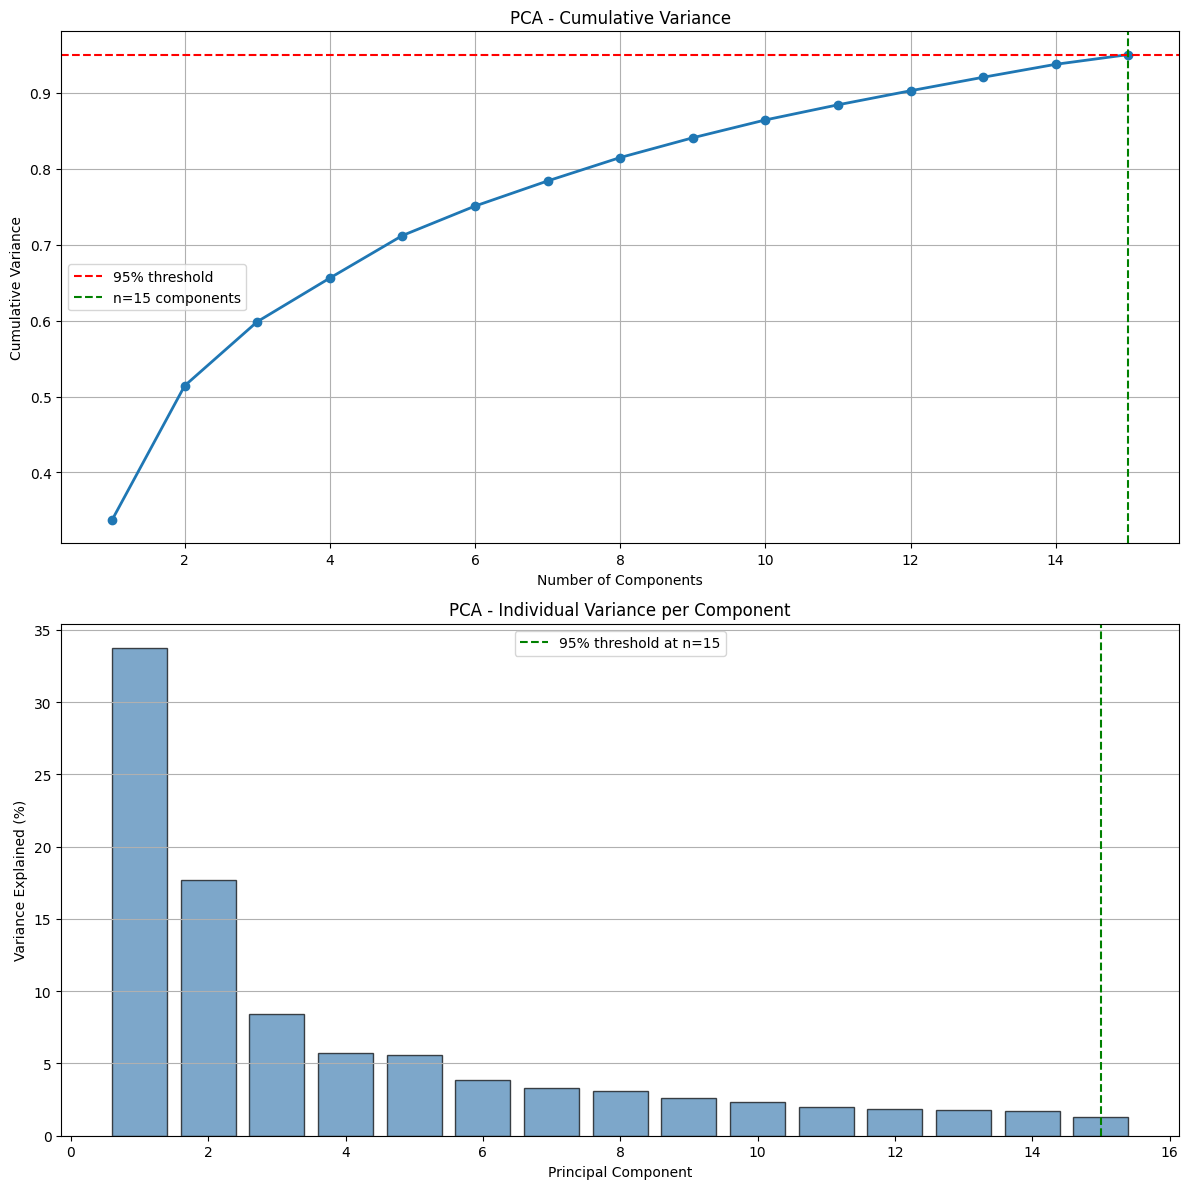

✅ Components needed for 95% variance: 15
✅ Variance explained by 15 components: 0.9505


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [12]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# lazyPredict

In [23]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [24]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

                               Adjusted R-Squared      R-Squared         RMSE  \
Model                                                                           
ExtraTreesRegressor                      0.408059       0.421137     7.369610   
HistGradientBoostingRegressor            0.405150       0.418293     7.387697   
RandomForestRegressor                    0.354103       0.368374     7.698159   
MLPRegressor                             0.339251       0.353850     7.786162   
BaggingRegressor                         0.316540       0.331641     7.918844   
KNeighborsRegressor                      0.314379       0.329528     7.931350   
XGBRegressor                             0.295008       0.310585     8.042613   
GradientBoostingRegressor                0.274879       0.290901     8.156623   
PoissonRegressor                         0.182081       0.200153     8.662842   
Lars                                     0.095207       0.115198     9.111288   
TransformedTargetRegressor  

# OpTuna

In [13]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor

In [26]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [27]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-06 09:04:58,283] A new study created in memory with name: no-name-5fe68fa0-bb07-4275-b260-38e8405e756b
[I 2026-05-06 09:04:59,099] Trial 0 finished with value: 0.29911042253417197 and parameters: {'n_estimators': 163, 'max_depth': 23, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.29911042253417197.
[I 2026-05-06 09:05:00,069] Trial 1 finished with value: 0.22557308948812974 and parameters: {'n_estimators': 258, 'max_depth': 40, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.29911042253417197.
[I 2026-05-06 09:05:01,137] Trial 2 finished with value: 0.1742511156919704 and parameters: {'n_estimators': 297, 'max_depth': 33, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.29911042253417197.
[I 2026-05-06 09:05:01,801] Trial 3 finished with value: 0.12854412855138297 and parameters: {'n_estimators': 201, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with 

========== ET BEST ==========
{'n_estimators': 111, 'max_depth': 32, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.3042


In [28]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-06 09:05:38,325] A new study created in memory with name: no-name-b4fe5864-960d-49af-947e-4a97d1d06672
[I 2026-05-06 09:05:39,643] Trial 0 finished with value: 0.16057315202291483 and parameters: {'n_estimators': 264, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.16057315202291483.
[I 2026-05-06 09:05:40,755] Trial 1 finished with value: 0.22348726929634646 and parameters: {'n_estimators': 145, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.22348726929634646.
[I 2026-05-06 09:05:41,753] Trial 2 finished with value: 0.21491287323253552 and parameters: {'n_estimators': 112, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.22348726929634646.
[I 2026-05-06 09:05:42,999] Trial 3 finished with value: 0.2243272806545745 and parameters: {'n_estimators': 155, 'max_depth': 

========== RF BEST ==========
{'n_estimators': 190, 'max_depth': 32, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.2572


In [29]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.95)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-06 09:07:27,399] A new study created in memory with name: no-name-66c45c29-7dd7-4023-b5af-10c02948d8b1
[I 2026-05-06 09:07:27,967] Trial 0 finished with value: 0.1933610847952887 and parameters: {'max_iter': 78, 'max_depth': 4, 'learning_rate': 0.09679700464405853, 'min_samples_leaf': 24, 'l2_regularization': 0.7247544433405765}. Best is trial 0 with value: 0.1933610847952887.
[I 2026-05-06 09:07:28,986] Trial 1 finished with value: 0.20560825867366264 and parameters: {'max_iter': 102, 'max_depth': 14, 'learning_rate': 0.03266917181983817, 'min_samples_leaf': 26, 'l2_regularization': 0.02640427773712184}. Best is trial 1 with value: 0.20560825867366264.
[I 2026-05-06 09:07:31,189] Trial 2 finished with value: 0.23642101374316457 and parameters: {'max_iter': 308, 'max_depth': 9, 'learning_rate': 0.014507857281194053, 'min_samples_leaf': 22, 'l2_regularization': 0.7918409106409315}. Best is trial 2 with value: 0.23642101374316457.
[I 2026-05-06 09:07:32,348] Trial 3 finished w

========== HGB BEST ==========
{'max_iter': 164, 'max_depth': 10, 'learning_rate': 0.08022417608998425, 'min_samples_leaf': 28, 'l2_regularization': 0.7544544718666345}
Best R²: 0.2470


# Start

In [14]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=164,
    max_depth=10,
    learning_rate=0.08,
    min_samples_leaf=28,
    l2_regularization=0.754,
    random_state=42
)
# {'max_iter': 164, 'max_depth': 10, 'learning_rate': 0.08022417608998425, 'min_samples_leaf': 28, 'l2_regularization': 0.7544544718666345}


et_model = ExtraTreesRegressor(
    n_estimators=111,
    max_depth=32,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# ========== ET BEST ==========
# {'n_estimators': 111, 'max_depth': 32, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


rf_model = RandomForestRegressor(
    n_estimators=190, 
    max_depth=32, 
    min_samples_split =  3,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)
# {'n_estimators': 190, 'max_depth': 32, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [15]:
from sklearn.metrics import mean_absolute_error


In [16]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('rf',  rf_model)
])

# Train all
hgb_model.fit(X_train_pca, y_train)
et_model.fit(X_train_pca, y_train)
rf_model.fit(X_train_pca, y_train)
voting.fit(X_train_pca, y_train)

models = {
    'HistGradientBoost': hgb_model,
    'ExtraTrees':        et_model,
    'RandomForest':      rf_model,
    'Voting (Ensemble)': voting
}

print("=" * 65)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 65)
print(f"{'Model':<22}{'R²':>10}{'RMSE':>12}{'MAE':>10}{'Acc%':>10}")
print("-" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{name:<22}{r2:>10.4f}{rmse:>12.4f}{mae:>10.4f}{100-mae:>10.2f}")
print("-" * 65)
print(f"{'Paper baseline:':<22}{0.6395:>10.4f}{12.9268:>12.4f}{'—':>10}{93.88:>10.2f}")
print("=" * 65)

BASELINE RESULTS (single seed = 42)
Model                         R²        RMSE       MAE      Acc%
-----------------------------------------------------------------
HistGradientBoost         0.4328      7.2952    3.5242     96.48
ExtraTrees                0.4451      7.2155    3.1459     96.85
RandomForest              0.4092      7.4450    3.4737     96.53
Voting (Ensemble)         0.4631      7.0971    3.2586     96.74
-----------------------------------------------------------------
Paper baseline:           0.6395     12.9268         —     93.88


# K-Fold

In [17]:
from sklearn.model_selection import KFold

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month    = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGraHoost':         hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_no_month):
        # Split numeric and month separately
        X_fold_train, X_fold_test = X_no_month.iloc[train_idx], X_no_month.iloc[test_idx]
        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_ss)
        X_test_pca  = pca.transform(X_test_ss)

        # Reattach month columns after PCA
        n_pcs   = X_train_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([pd.DataFrame(X_train_pca, columns=pc_cols), month_fold_train], axis=1)
        X_test_final  = pd.concat([pd.DataFrame(X_test_pca,  columns=pc_cols), month_fold_test ], axis=1)

        # Train & evaluate (clone to avoid refitting same instance)
        from sklearn.base import clone
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.3786        7.5491        3.2035
RandomForest                  0.3282        7.8535        3.4661
HistGraHoost                  0.3288        7.8366        3.5812
Voting (Ensemble)             0.3763        7.5647        3.2863
